# PaDiM baseline on MVTec `grid`

Fit a per-pixel Gaussian model on the training features of the `good` class, then score test images. This notebook reproduces the `grid` result shown in the README.

**Method summary.** For each spatial location `(h, w)` of the ResNet-18 layer3 feature map, fit `N(mu_hw, Sigma_hw)` over the training features at that location. At inference, the anomaly score for a location is the Mahalanobis distance from that location's fitted Gaussian.

Reference: Defard et al., *PaDiM: a Patch Distribution Modeling Framework*, ICPR 2020.

In [2]:
import sys
sys.path.append("..")   # so we can import from src/

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from src.dataset import MVTecDataset, IMAGENET_MEAN, IMAGENET_STD
from src.features import FeatureExtractor
from src.methods import GaussianAD
from src.visualize import upsample_and_smooth, plot_anomaly

CATEGORY = "grid"
DATA_ROOT = "../data/mvtec"
IMAGE_SIZE = 224
BATCH_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Data

The `grid` category has ~264 training images (all `good`) and a test set split across `good` plus several defect types (`bent`, `broken`, `glue`, `metal_contamination`, `thread`).

In [3]:
tfm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = MVTecDataset(DATA_ROOT, CATEGORY, is_train=True, transform=tfm)
test_ds  = MVTecDataset(DATA_ROOT, CATEGORY, is_train=False, transform=tfm)

print(f"train : {len(train_ds)} images (all good)")
print(f"test  : {len(test_ds)} images across defect types: {test_ds.defect_types()}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)

train : 264 images (all good)
test  : 78 images across defect types: ['bent', 'broken', 'glue', 'good', 'metal_contamination', 'thread']


## Feature extractor

Pretrained ResNet-18, truncated at `layer3`. Output shape is `(256, 14, 14)` per image at 224x224 input. All parameters frozen.

In [4]:
extractor = FeatureExtractor(stop_layer="layer3").to(device)
print(f"output channels: {extractor.num_channels}")
print(f"trainable params: {sum(p.numel() for p in extractor.parameters() if p.requires_grad)}")

output channels: 256
trainable params: 0


## Fit the Gaussian model

For each of the 14×14 spatial positions, compute the mean and (diagonal) variance of the 256-channel feature vectors over the 264 training images. Storage: two tensors of shape `(256, 14, 14)`.

In [5]:
%%time
model = GaussianAD(diag_only=True)
model.fit(extractor, train_loader, device)
print("mean shape :", model.mean.shape)
print("inv_cov shape:", model.inv_cov.shape)

mean shape : torch.Size([256, 14, 14])
inv_cov shape: torch.Size([256, 14, 14])
CPU times: user 4min 57s, sys: 2.9 s, total: 5min
Wall time: 32.9 s


## Score and visualize test images

Pick one defective image, compute its Mahalanobis score map, upsample to 224×224, smooth with a Gaussian filter, and overlay.

showing indices: {'bent': 0, 'broken': 12, 'glue': 24}


/tmp/ipykernel_168854/151025552.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


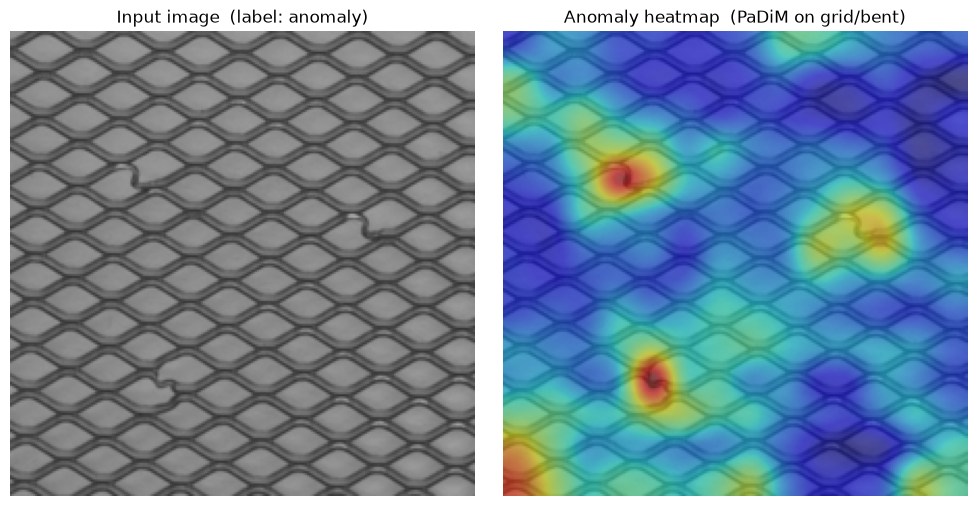

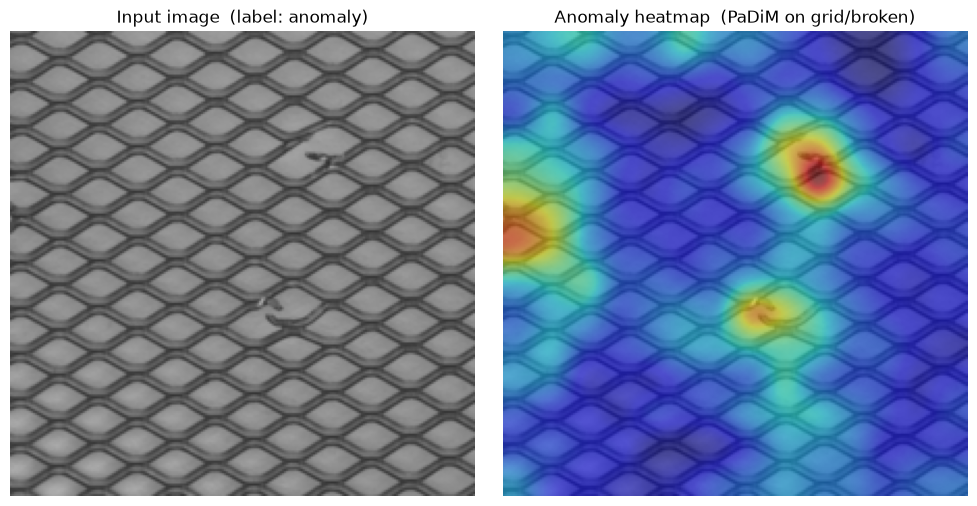

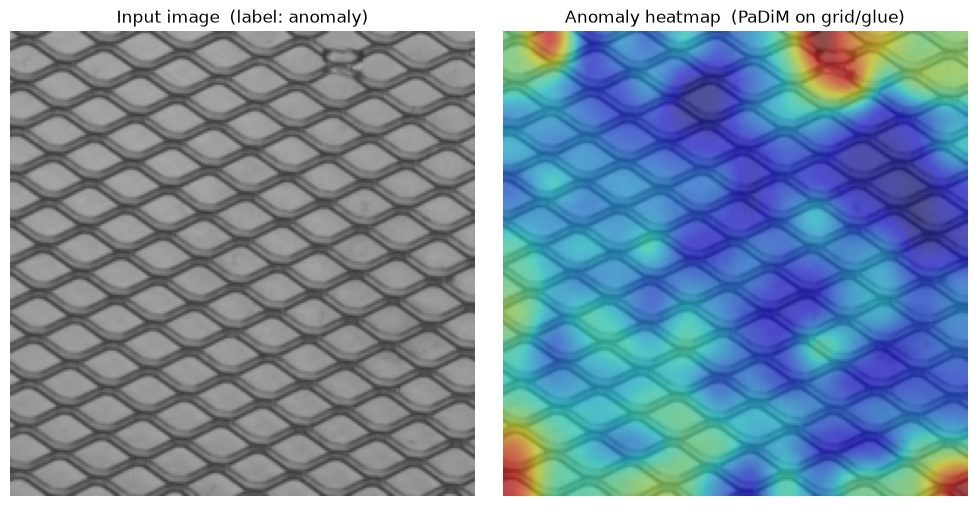

In [6]:
# Pick the first defective image of each defect type
seen = {}
for i, path in enumerate(test_ds.image_paths):
    defect = path.split("/")[-2]
    if defect != "good" and defect not in seen:
        seen[defect] = i
    if len(seen) == 3:   # first 3 defect types is enough for the notebook
        break

print("showing indices:", seen)

for defect, idx in seen.items():
    img, lbl = test_ds[idx]
    fmap = extractor(img.unsqueeze(0).to(device)).squeeze(0)
    score = model.score(fmap)
    heatmap = upsample_and_smooth(score, out_size=IMAGE_SIZE, sigma=4.0)

    fig = plot_anomaly(img, heatmap, label=lbl, method_name=f"PaDiM on grid/{defect}")
    fig.show()

## Analysis

PaDiM works well on `grid` because the category is a repetitive, position-locked texture: every training image looks essentially the same at every pixel. That makes the per-location Gaussians tight, so any deviation stands out sharply. The heatmaps localize the broken wires, bent regions, and contamination with minimal background noise.

The failure mode of PaDiM shows up on categories with object-level variation (pose, rotation, lighting). See `03_knn_method.ipynb` for the `pill` case where PaDiM fires on the object boundary and misses the actual defect.